# 📊 EDA — SceneStructNet Dataset
Exploratory Data Analysis for the SceneStructNet (SSN) project.  
**Goal**: Detect vertical edge lines (tilt angle vs Y-axis) + ground-region ratio in images.

---

## 0. Setup & Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATASET_ROOT = Path('../raw_datasets')
SOURCES = ['google_image', 'pinterest']
SUPPORTED_EXT = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

print('Dataset root:', DATASET_ROOT.resolve())

Dataset root: /home/infinitydreamer/Desktop/SceneStructNet/raw_datasets


## 1. Scan Dataset — Build Image Registry

In [2]:
records = []

for source in SOURCES:
    source_dir = DATASET_ROOT / source
    if not source_dir.exists():
        print(f'[WARN] Source not found: {source_dir}')
        continue
    for category_dir in sorted(source_dir.iterdir()):
        if not category_dir.is_dir():
            continue
        category = category_dir.name
        for img_path in category_dir.iterdir():
            if img_path.suffix.lower() in SUPPORTED_EXT:
                records.append({
                    'path': str(img_path),
                    'source': source,
                    'category': category,
                    'filename': img_path.name,
                    'ext': img_path.suffix.lower(),
                    'size_bytes': img_path.stat().st_size
                })

df = pd.DataFrame(records)
print(f'Total images found: {len(df)}')
df.head()

Total images found: 1150


,path,source,category,filename,ext,size_bytes
0,../raw_datasets/google_image/architecture_phot...,google_image,architecture_photography,c4555afc8ca404edae3ffa22603b264cca90d5f0.jpg,.jpg,517778
1,../raw_datasets/google_image/architecture_phot...,google_image,architecture_photography,abe8816976dce316a39380b15cbf909887a76aaf.jpg,.jpg,177720
2,../raw_datasets/google_image/architecture_phot...,google_image,architecture_photography,dd5dd611ac1b4e83ab35bcc1c1da262e4e22d33c.jpg,.jpg,199080
3,../raw_datasets/google_image/architecture_phot...,google_image,architecture_photography,cb09fb2a621a3bd069de7cb7d700089b9989cb21.jpg,.jpg,78187
4,../raw_datasets/google_image/architecture_phot...,google_image,architecture_photography,bc88d3ffd0df08bd5b47f7189a10892b2490ea99.png,.png,1811168


## 2. Dataset Overview

In [3]:
print('=== Summary ===')
print(f'Total images  : {len(df)}')
print(f'Sources       : {df["source"].nunique()} → {df["source"].unique().tolist()}')
print(f'Categories    : {df["category"].nunique()}')
print(f'File formats  : {df["ext"].value_counts().to_dict()}')
print()

pivot = df.groupby(['source', 'category']).size().reset_index(name='count')
print(pivot.to_string(index=False))

=== Summary ===
Total images  : 1150
Sources       : 2 → ['google_image', 'pinterest']
Categories    : 4
File formats  : {'.jpg': 1002, '.png': 80, '.jpeg': 44, '.webp': 24}

      source                         category  count
google_image         architecture_photography    168
google_image                 city_photography    177
google_image            photography_no_people    136
google_image street_style_fashion_photography     89
   pinterest         architecture_photography    185
   pinterest                 city_photography    295
   pinterest street_style_fashion_photography    100


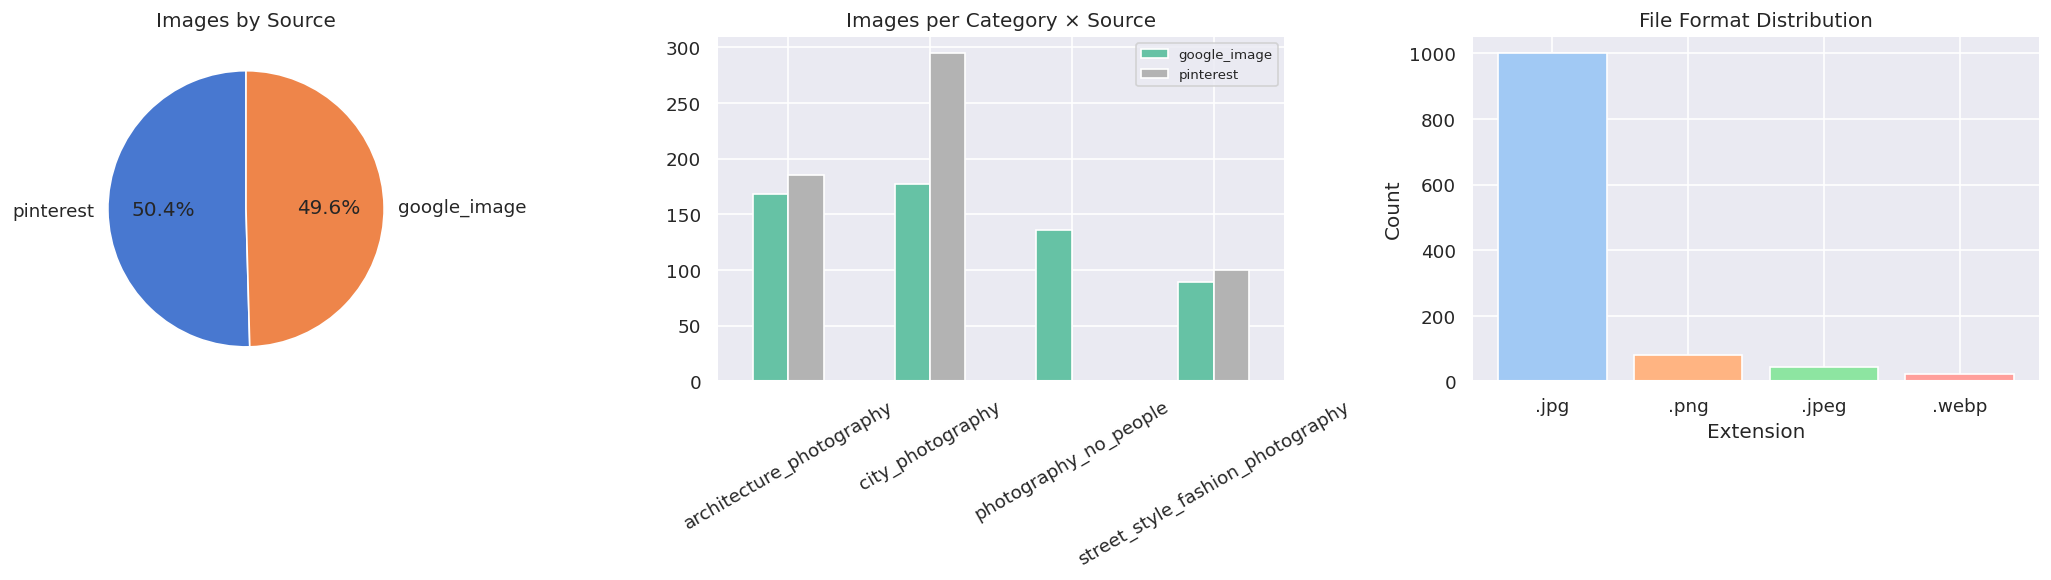

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Count by source
src_counts = df['source'].value_counts()
axes[0].pie(src_counts, labels=src_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Images by Source')

# Count by category (stacked bar)
cat_src = df.groupby(['category', 'source']).size().unstack(fill_value=0)
cat_src.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Images per Category × Source')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=8)

# File format
ext_counts = df['ext'].value_counts()
axes[2].bar(ext_counts.index, ext_counts.values, color=sns.color_palette('pastel'))
axes[2].set_title('File Format Distribution')
axes[2].set_xlabel('Extension')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 3. Image Metadata — Resolution & Aspect Ratio

In [5]:
def get_image_meta(path):
    try:
        with Image.open(path) as img:
            w, h = img.size
            mode = img.mode
        return w, h, mode
    except Exception:
        return None, None, None

meta = [get_image_meta(p) for p in tqdm(df['path'], desc='Reading metadata')]
df['width'], df['height'], df['mode'] = zip(*meta)
df = df.dropna(subset=['width', 'height'])
df['width'] = df['width'].astype(int)
df['height'] = df['height'].astype(int)
df['aspect_ratio'] = (df['width'] / df['height']).round(3)
df['mpx'] = (df['width'] * df['height'] / 1e6).round(2)
df['orientation'] = df.apply(lambda r: 'portrait' if r['height'] > r['width'] else ('landscape' if r['width'] > r['height'] else 'square'), axis=1)

df[['width', 'height', 'aspect_ratio', 'mpx', 'orientation']].describe()

Reading metadata: 100%|██████████| 1150/1150 [00:00<00:00, 8908.11it/s]


,width,height,aspect_ratio,mpx
count,1150.000000,1150.000000,1150.000000,1150.000000
mean,1410.560000,1438.546087,1.034307,2.531078
std,862.508129,830.634741,0.459596,3.792469
min,236.000000,353.000000,0.462000,0.080000
25%,800.250000,947.750000,0.667000,0.900000
50%,1200.000000,1250.000000,0.800000,1.460000
75%,1620.000000,1667.000000,1.499000,2.605000
max,6414.000000,7360.000000,3.987000,36.150000


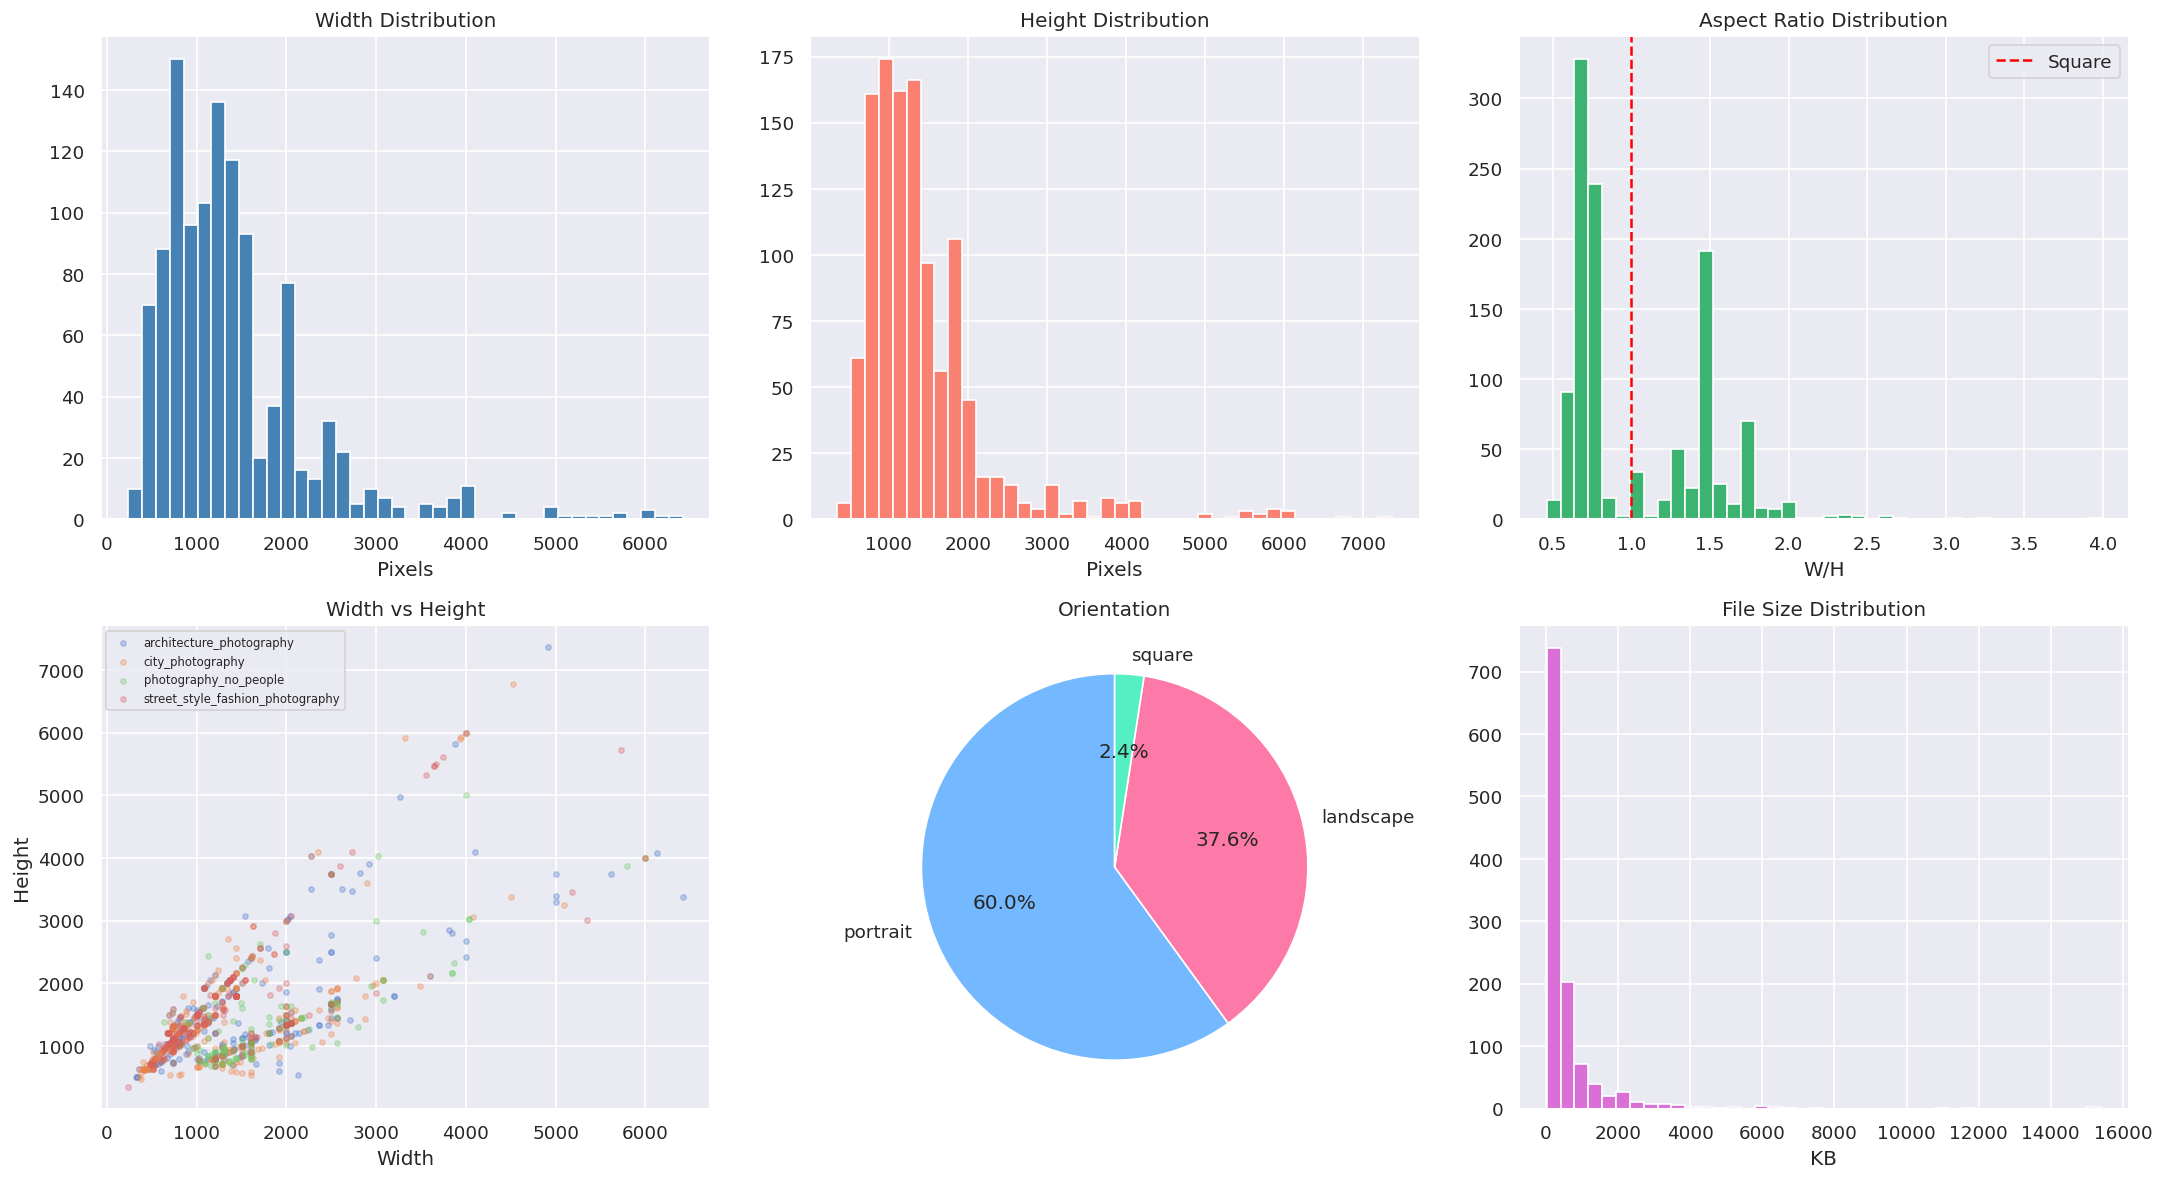

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Width distribution
axes[0,0].hist(df['width'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Width Distribution')
axes[0,0].set_xlabel('Pixels')

# Height distribution
axes[0,1].hist(df['height'], bins=40, color='salmon', edgecolor='white')
axes[0,1].set_title('Height Distribution')
axes[0,1].set_xlabel('Pixels')

# Aspect ratio
axes[0,2].hist(df['aspect_ratio'], bins=40, color='mediumseagreen', edgecolor='white')
axes[0,2].axvline(1.0, color='red', linestyle='--', label='Square')
axes[0,2].set_title('Aspect Ratio Distribution')
axes[0,2].set_xlabel('W/H')
axes[0,2].legend()

# W vs H scatter
for cat, grp in df.groupby('category'):
    axes[1,0].scatter(grp['width'], grp['height'], alpha=0.3, s=10, label=cat)
axes[1,0].set_title('Width vs Height')
axes[1,0].set_xlabel('Width')
axes[1,0].set_ylabel('Height')
axes[1,0].legend(fontsize=7)

# Orientation pie
ori = df['orientation'].value_counts()
axes[1,1].pie(ori, labels=ori.index, autopct='%1.1f%%', startangle=90, colors=['#74b9ff','#fd79a8','#55efc4'])
axes[1,1].set_title('Orientation')

# File size distribution
axes[1,2].hist(df['size_bytes']/1024, bins=40, color='orchid', edgecolor='white')
axes[1,2].set_title('File Size Distribution')
axes[1,2].set_xlabel('KB')

plt.tight_layout()
plt.show()

## 4. Resolution Grouping & Common Sizes

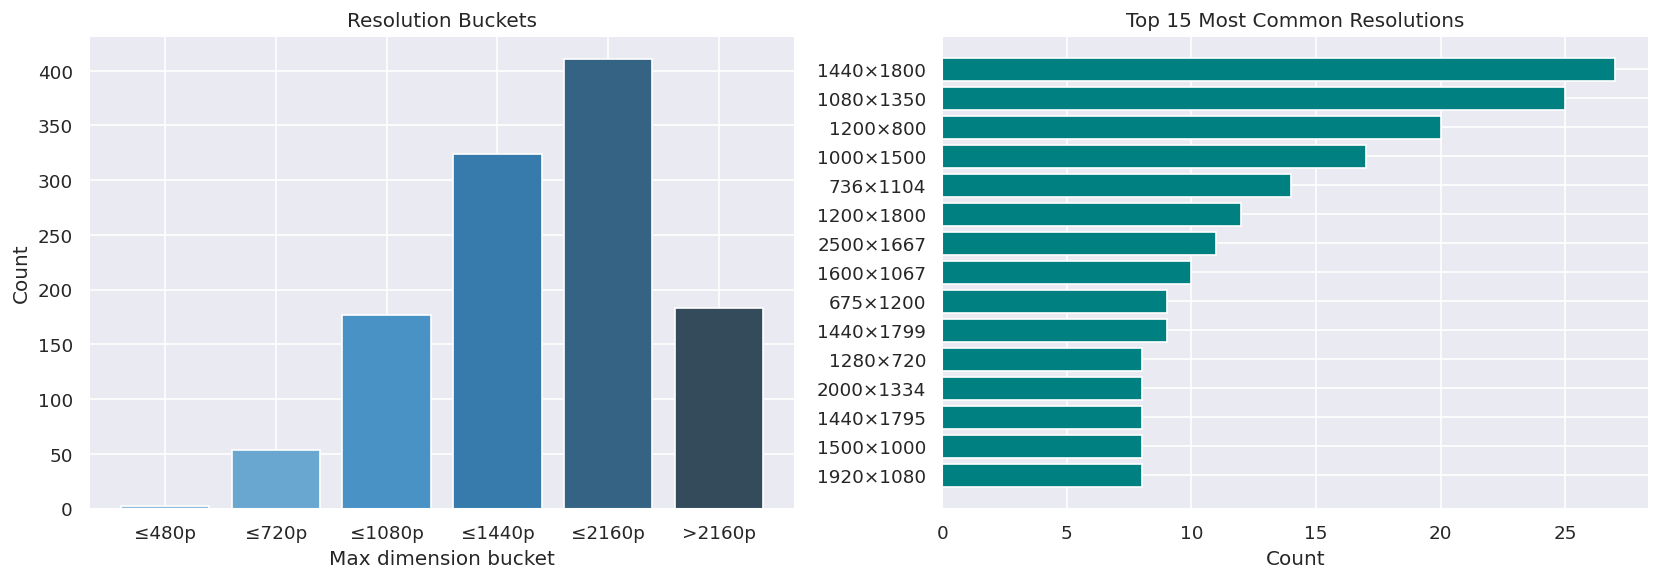

In [7]:
def bucket_res(w, h):
    for t in [480, 720, 1080, 1440, 2160]:
        if max(w,h) <= t:
            return f'≤{t}p'
    return '>2160p'

df['res_bucket'] = df.apply(lambda r: bucket_res(r['width'], r['height']), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bucket_order = ['≤480p','≤720p','≤1080p','≤1440p','≤2160p','>2160p']
rb = df['res_bucket'].value_counts().reindex(bucket_order, fill_value=0)
axes[0].bar(rb.index, rb.values, color=sns.color_palette('Blues_d', len(rb)))
axes[0].set_title('Resolution Buckets')
axes[0].set_xlabel('Max dimension bucket')
axes[0].set_ylabel('Count')

top_sizes = df.groupby(['width','height']).size().sort_values(ascending=False).head(15)
labels = [f'{w}×{h}' for w,h in top_sizes.index]
axes[1].barh(labels[::-1], top_sizes.values[::-1], color='teal')
axes[1].set_title('Top 15 Most Common Resolutions')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

## 5. Sample Image Grid per Category

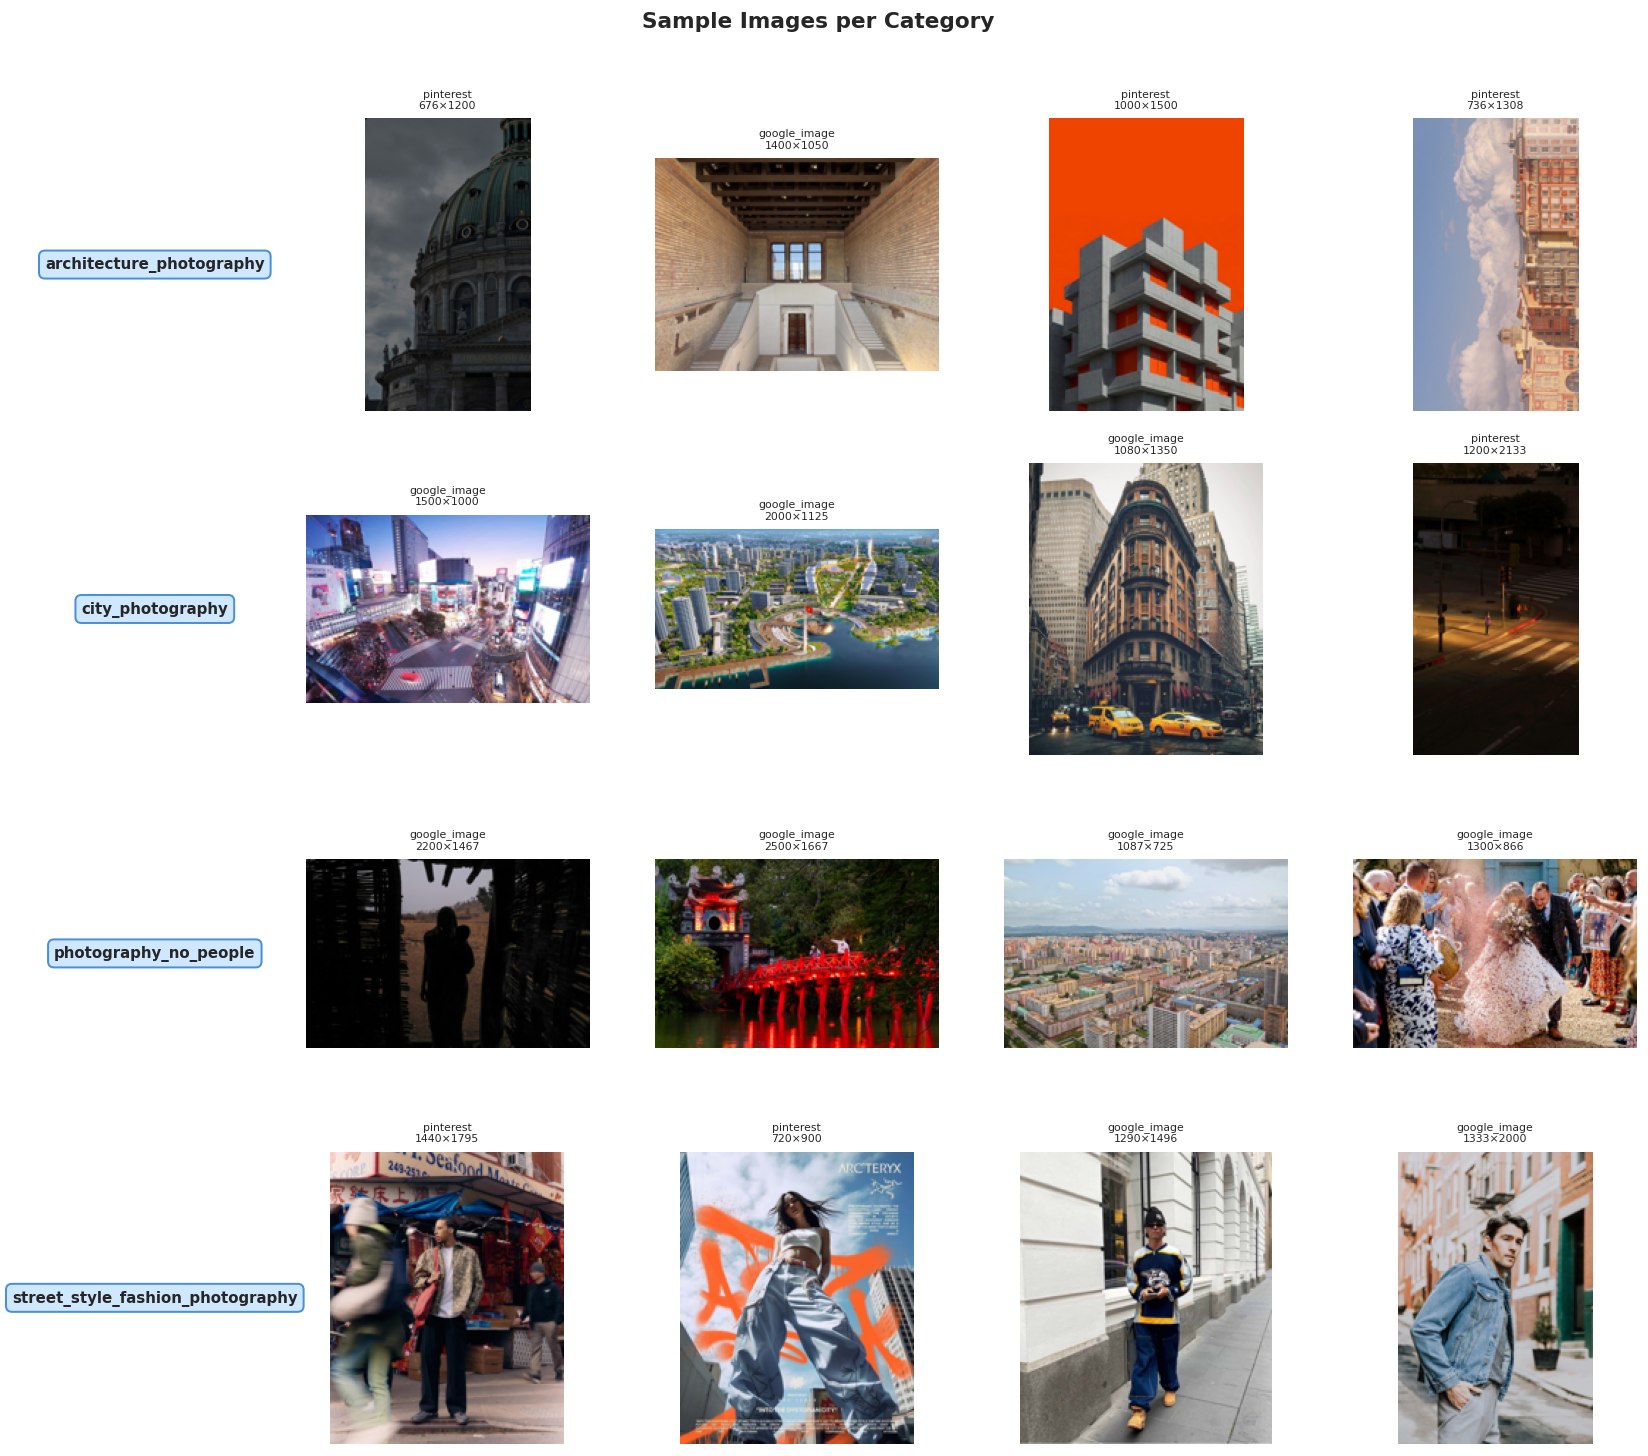

In [ ]:
def show_samples(df, n_per_cat=4, target_size=(200, 200)):
    cats = df['category'].unique()
    n_cols = n_per_cat + 1
    fig, axes = plt.subplots(len(cats), n_cols,
                             figsize=(n_cols * 2.8, len(cats) * 3),
                             gridspec_kw={'width_ratios': [1.2] + [2] * n_per_cat})
    if len(cats) == 1:
        axes = [axes]

    for row_i, cat in enumerate(cats):
        label_ax = axes[row_i][0]
        label_ax.axis('off')
        label_ax.text(0.5, 0.5, cat,
                      ha='center', va='center', fontsize=9,
                      fontweight='bold', wrap=True,
                      bbox=dict(boxstyle='round,pad=0.4', facecolor='#d0e8ff', edgecolor='#4a90d9', linewidth=1.2))

        cat_df = df[df['category'] == cat]
        samples = cat_df.sample(min(n_per_cat, len(cat_df)), random_state=42)

        for col_i, (_, row) in enumerate(samples.iterrows()):
            ax = axes[row_i][col_i + 1]
            try:
                img = Image.open(row['path']).convert('RGB')
                img.thumbnail(target_size)
                ax.imshow(img)
                ax.set_title(f"{row['source']}\n{row['width']}\u00d7{row['height']}", fontsize=6.5)
            except Exception:
                ax.text(0.5, 0.5, 'Error loading', ha='center', va='center', fontsize=8)
            ax.axis('off')

        for col_i in range(len(samples), n_per_cat):
            axes[row_i][col_i + 1].axis('off')

    plt.suptitle('Sample Images per Category', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

show_samples(df, n_per_cat=4)